<a href="https://colab.research.google.com/github/nirajsingh916262-debug/rabtech-task-2/blob/main/rabtech_task_4_pca_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)

In [ ]:
from sklearn.datasets import make_blobs

# Create a synthetic high-dimensional dataset
X, y = make_blobs(
    n_samples=200,
    n_features=6,
    centers=3,
    cluster_std=2.0,
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(
    X,
    columns=[
        'Feature_1',
        'Feature_2',
        'Feature_3',
        'Feature_4',
        'Feature_5',
        'Feature_6'
    ]
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (200, 6)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6
0,-5.547938,8.045818,7.173701,0.557831,-5.991988,-5.330841
1,3.535689,-6.609448,-3.361981,-4.631466,-4.612459,-0.203387
2,-2.483194,11.921354,4.110565,7.413508,-5.628292,-8.594425
3,-4.650983,9.979231,4.192953,3.401171,-5.933152,-7.025767
4,-0.192976,10.597612,5.888118,3.229861,-6.904121,-8.674618


In [ ]:
# Standardize the features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Standardized dataset shape:", X_scaled.shape)

Standardized dataset shape: (200, 6)


In [ ]:
# Apply PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Original features:", X_scaled.shape[1])
print("PCA components:", X_pca.shape[1])

Original features: 6
PCA components: 6


In [ ]:
# Explained Variance Ratio

explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
for i, value in enumerate(explained_variance, start=1):
    print(f"PC{i}: {value:.4f}")

print("\nCumulative Explained Variance:")
print(np.cumsum(explained_variance))

Explained Variance Ratio:
PC1: 0.6662
PC2: 0.2241
PC3: 0.0488
PC4: 0.0266
PC5: 0.0218
PC6: 0.0125

Cumulative Explained Variance:
[0.66622059 0.89031463 0.93912282 0.96576008 0.98751661 1.        ]


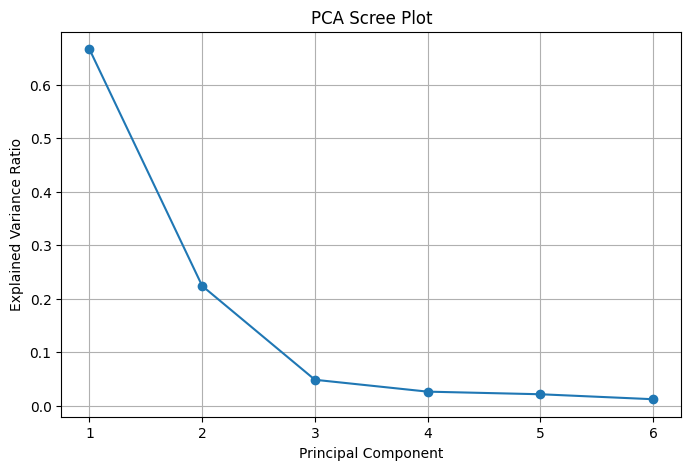

In [ ]:
# Scree Plot

plt.figure(figsize=(8, 5))

components = range(1, len(explained_variance) + 1)

plt.plot(
    components,
    explained_variance,
    marker='o'
)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Scree Plot')
plt.xticks(components)
plt.grid(True)

plt.show()

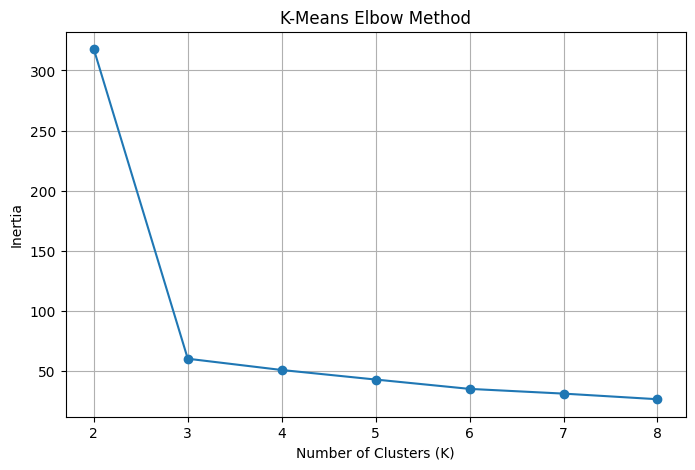

In [ ]:

# Elbow Method for K-Means

inertias = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_pca[:, :2])
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), inertias, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('K-Means Elbow Method')
plt.xticks(range(2, 9))
plt.grid(True)

plt.show()

In [ ]:
# Final K-Means Clustering

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca[:, :2])

silhouette = silhouette_score(X_pca[:, :2], clusters)

print("Silhouette Score:", round(silhouette, 4))
print("Number of clusters:", 3)

Silhouette Score: 0.7786
Number of clusters: 3


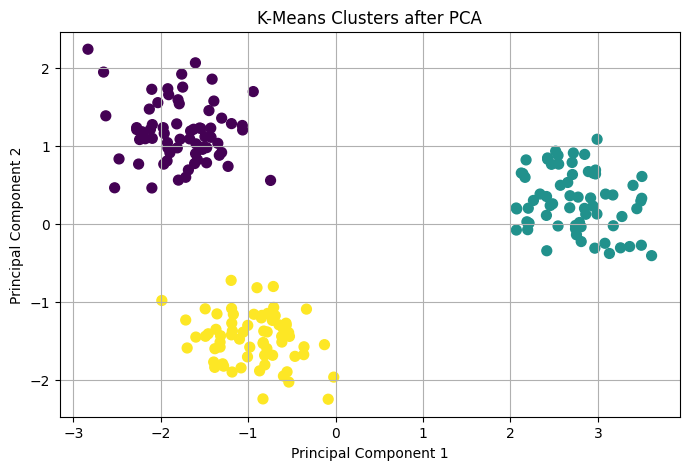

In [ ]:
# 2D Cluster Visualization

plt.figure(figsize=(8, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    s=50
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters after PCA')
plt.grid(True)

plt.show()

In [ ]:

# Final Findings and Conclusion

print("FINAL FINDINGS")
print("=" * 50)

print("1. PCA was applied after standardizing the dataset.")

print("\n2. The Scree Plot and explained variance ratio were")
print("   used to understand the contribution of each component.")

print("\n3. K-Means clustering was evaluated using the Elbow Method.")

print("\n4. Silhouette Score was calculated to assess cluster quality.")

print("\n5. PCA reduced the data to two principal components for")
print("   visualization of the K-Means clusters.")

print("\n6. The final clusters were visualized in a 2D PCA plot.")

print("\nDataset note: This notebook uses a synthetic dataset")
print("created for Task 4 demonstration and reproducibility.")

FINAL FINDINGS
1. PCA was applied after standardizing the dataset.

2. The Scree Plot and explained variance ratio were
   used to understand the contribution of each component.

3. K-Means clustering was evaluated using the Elbow Method.

4. Silhouette Score was calculated to assess cluster quality.

5. PCA reduced the data to two principal components for
   visualization of the K-Means clusters.

6. The final clusters were visualized in a 2D PCA plot.

Dataset note: This notebook uses a synthetic dataset
created for Task 4 demonstration and reproducibility.


# Standardize the features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Standardized dataset shape:", X_scaled.shape)

from sklearn.datasets import make_blobs

# Create a synthetic high-dimensional dataset
X, y = make_blobs(
    n_samples=200,
    n_features=6,
    centers=3,
    cluster_std=2.0,
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(
    X,
    columns=[
        'Feature_1',
        'Feature_2',
        'Feature_3',
        'Feature_4',
        'Feature_5',
        'Feature_6'
    ]
)

print("Dataset shape:", df.shape)
df.head()